
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       222
           1       0.86      0.81      0.83       195

    accuracy                           0.85       417
   macro avg       0.85      0.85      0.85       417
weighted avg       0.85      0.85      0.85       417


Confusion Matrix:


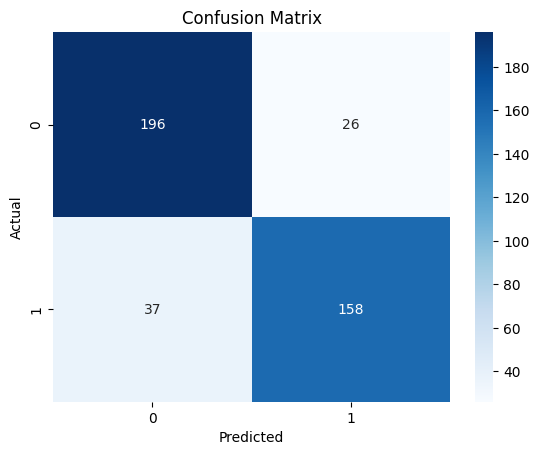


ROC-AUC Score: 0.8466

Cross-Validation ROC-AUC Scores: [0.7789501  0.83861746 0.83430353 0.81565577 0.82102451]
Average CV ROC-AUC: 0.8177 (+/- 0.0422)


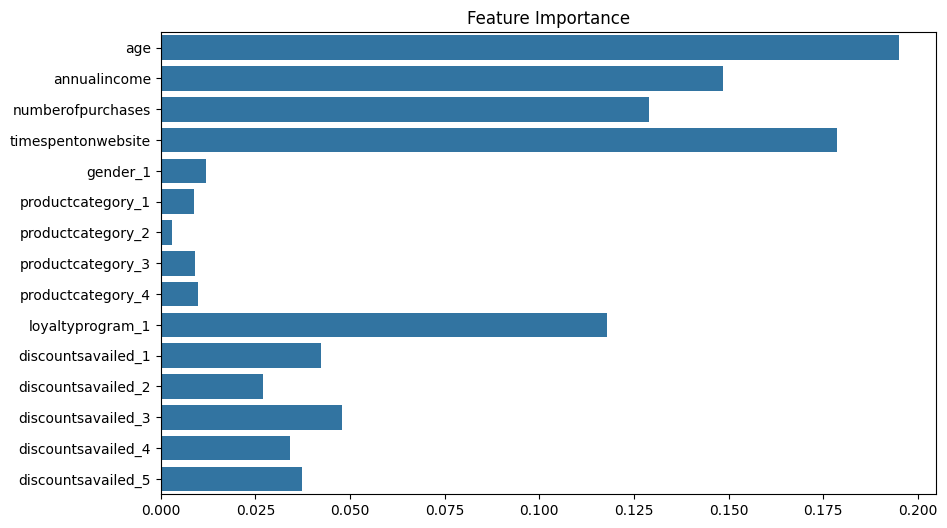


Best Parameters from Grid Search: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 6, 'classifier__min_samples_split': 2}
Best ROC-AUC Score: 0.8601

Final Model Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       222
           1       0.84      0.84      0.84       195

    accuracy                           0.85       417
   macro avg       0.85      0.85      0.85       417
weighted avg       0.85      0.85      0.85       417



In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the Cleaned Dataset
df = pd.read_csv('cleaned_customer_purchases.csv')
df_t = df.copy()  # Assuming df_1 is the cleaned DataFrame
X = df_t.drop('purchasestatus', axis=1)
y = df_t['purchasestatus']

# Step 2: Preprocess Data
numerical_cols = ['age', 'annualincome', 'numberofpurchases', 'timespentonwebsite']
categorical_cols = ['gender', 'productcategory', 'loyaltyprogram', 'discountsavailed']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

# Step 3: Build Model Pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(class_weight='balanced', random_state=35))
])

# Step 4: Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=35, stratify=y)

# Step 5: Train the Model
model.fit(X_train, y_train)

# Step 6: Evaluate the Model
y_pred = model.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

y_pred_proba = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# Step 7: Cross-Validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
print(f"\nCross-Validation ROC-AUC Scores: {cv_scores}")
print(f"Average CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Step 8: Feature Importance
ohe = model.named_steps['preprocessor'].named_transformers_['cat']
feature_names = numerical_cols + list(ohe.get_feature_names_out(categorical_cols))
importances = model.named_steps['classifier'].feature_importances_
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names)
plt.title('Feature Importance')
plt.show()

# Step 9: Hyperparameter Tuning
param_grid = {
    'classifier__max_depth': [None, 10, 20, 30,40],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4,6]
}
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("\nBest Parameters from Grid Search:", grid_search.best_params_)
print(f"Best ROC-AUC Score: {grid_search.best_score_:.4f}")

# Step 10: Final Model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print("\nFinal Model Classification Report:")
print(classification_report(y_test, y_pred_best))